# V1 Walking Skeleton — Defensive Playcall Causal RL

This notebook runs the **entire V1 pipeline end-to-end** and narrates what each
stage does and *why*. It calls the exact same `src/` modules as `run_v1.py`, so
it is a live, executable walkthrough — not a separate reimplementation.

**What V1 is (and isn't).** Per the project's walking-skeleton-first rule, V1 is
deliberately simple and *wrong in places by design*. The goal is a debuggable
pipeline that produces **and evaluates** a defensive policy — not a trustworthy
model. The parts that are wrong are exactly the parts V2 upgrades, and this
notebook points them out as they appear.

**Scope:** 3rd downs only · one team's defense (SF) · 2021–2023 ·
4 actions = {man, zone} × {blitz, no-blitz}.

**Pipeline:** data → SCM → behavior policy π_b → outcome model Q → off-policy
evaluation (OPE) → behavior-constrained greedy policy.

## Setup

We locate the repo root (so relative paths like `configs/v1.yaml` and the cached
play-by-play in `data/raw/` resolve), put it on the import path, and load the V1
config — the single source of truth for scope and hyperparameters.

In [ ]:
import os, sys, warnings

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Put the repo root (the directory containing configs/) on the import path so the
# `from src...` project imports below resolve. This bootstrap has to run *before*
# those imports, which is why it lives here in the imports cell rather than lower.
here = os.getcwd()
root = here if os.path.exists(os.path.join(here, "configs")) else os.path.dirname(here)
os.chdir(root)
sys.path.insert(0, root)

# Project pipeline — one import per component, in the order the notebook uses them.
from src.data.load import load_pbp
from src.data.features import build_v1_dataset, time_aware_split
from src.scm import graph as scm
from src.models.behavior.propensity import fit_behavior_model
from src.models.outcome.q_model import fit_q_model
from src.ope.direct_method import behavior_recovery_check, dm_policy_value
from src.policy.greedy import learn_greedy_policy

In [ ]:
pd.set_option("display.float_format", lambda v: f"{v:+.4f}")

with open("configs/v1.yaml") as f:
    cfg = yaml.safe_load(f)
np.random.seed(cfg["seed"])
cfg["data"]["team"], cfg["data"]["seasons"], cfg["data"]["holdout_season"]

## Step 1 — Data layer: raw play-by-play → (S, A, R)

The data layer turns nflfastR play-by-play into a clean **(State, Action,
Reward)** table for one team's 3rd-down defense.

- **State (S)** — *pre-snap only*. Down/distance, field position, score, clock,
  timeouts, offensive formation & personnel, and a **lagged** offensive
  pass-tendency (expanding mean shifted by one play, so no post-snap information
  leaks in). Any leakage here would invalidate the whole causal story.
- **Action (A)** — the 4-way defensive call, built from charted columns:
  `defense_man_zone_type` (man/zone) × `number_of_pass_rushers ≥ 5` (blitz).
  Plays with no charted coverage are dropped rather than guessed.
- **Reward (R)** — `−EPA`. The defense wants to *minimize* the offense's expected
  points, so we negate EPA and then everything downstream simply *maximizes* R.

In [ ]:
pbp = load_pbp(cfg["data"]["seasons"], cfg["data"]["cache_dir"])   # cached parquet
ds = build_v1_dataset(pbp, cfg)
print(f"{len(pbp):,} raw plays  ->  {len(ds.df):,} plays in the V1 slice "
      f"({cfg['data']['team']} 3rd downs)")

dist = (ds.df[ds.action_col].map(ds.action_labels)
        .value_counts().rename_axis("action").rename("plays").to_frame())
dist["share"] = dist["plays"] / dist["plays"].sum()
dist

Notice the **class imbalance**: `zone_no_blitz` dominates while `zone_blitz`
is rare. That imbalance is the first hint of a *positivity* problem — for some
situations the DC almost never dials up certain calls, so the data can't tell us
much about those calls there. We come back to this when constraining the policy.

In [3]:
# Quick look at the state features (pre-snap only — no epa/reward here).
ds.df[ds.state_cols].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
ydstogo,+7.7089,+5.0397,+1.0000,+30.0000
yardline_100,+51.9339,+24.2234,+1.0000,+99.0000
score_diff,-5.3196,+9.6058,-35.0000,+21.0000
game_seconds_remaining,+1738.5482,+1048.7686,+6.0000,+3563.0000
half_seconds_remaining,+844.9768,+536.3168,+6.0000,+1789.0000
qtr,+2.5554,+1.1351,+1.0000,+5.0000
posteam_timeouts_remaining,+2.6232,+0.7465,+0.0000,+3.0000
defteam_timeouts_remaining,+2.6714,+0.5699,+0.0000,+3.0000
shotgun,+0.9750,+0.1563,+0.0000,+1.0000
no_huddle,+0.1214,+0.3269,+0.0000,+1.0000


### Time-aware split

We **never** split randomly across plays — that would leak future games into the
past. We hold out the most recent season and train on the earlier ones, mimicking
how the tool would actually be used (learn from history, evaluate on the future).

In [4]:
train, test = time_aware_split(ds, cfg["data"]["holdout_season"])
print(f"train: {len(train.df):,} plays (seasons < {cfg['data']['holdout_season']})")
print(f"holdout: {len(test.df):,} plays (season >= {cfg['data']['holdout_season']})")

train: 350 plays (seasons < 2023)
holdout: 210 plays (season >= 2023)


## Step 2 — Causal graph (SCM skeleton)

Before modeling anything we commit to a **causal graph**. Its job is to
discipline what every downstream model is allowed to condition on. Two rulings
matter most in V1:

1. **The offensive playcall is a mediator** of A → R (the defense's call
   influences what the offense does, which influences the outcome). We must
   **not** condition on it when estimating the call's total effect — doing so
   would block part of the very effect we want to measure.
2. **The coach's hidden pre-snap read (`coach_read`) is an unobserved
   confounder** — it drives both which call the DC makes *and* the outcome. In
   V1 it's unmeasured, so our estimates carry residual confounding. We record
   that assumption explicitly here; V2 adds the sensitivity analysis that bounds
   its impact.

In [ ]:
print(scm.describe())

In [ ]:
# Draw the V1 DAG (no networkx dependency — laid out by hand).
pos = {"game_state": (0, 2), "coach_read": (2.2, 2), "off_playcall": (-2, 0),
       "def_playcall": (0, 0), "epa": (0, -2)}
labels = {"game_state": "Game State (S)", "coach_read": "Coach Read (U)\nunobserved",
          "off_playcall": "Off Playcall\n(mediator)", "def_playcall": "Def Playcall (A)\ntreatment",
          "epa": "EPA (R)\noutcome"}
colors = {"game_state": "#4A90D9", "coach_read": "#D98BA0", "off_playcall": "#C9C9C9",
          "def_playcall": "#E8A33D", "epa": "#7EC8A4"}

fig, ax = plt.subplots(figsize=(8, 5.5))
for n, (x, y) in pos.items():
    ax.scatter([x], [y], s=6500, c=colors[n], zorder=3, edgecolors="k")
    ax.text(x, y, labels[n], ha="center", va="center", fontsize=9, zorder=4)
for s, t in scm.EDGES:
    x0, y0 = pos[s]; x1, y1 = pos[t]
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), zorder=2,
                arrowprops=dict(arrowstyle="-|>", lw=1.6, color="#444",
                                shrinkA=42, shrinkB=42))
ax.set_xlim(-3.4, 3.6); ax.set_ylim(-3, 3); ax.axis("off")
ax.set_title("V1 Structural Causal Model", fontsize=13)
plt.tight_layout(); plt.show()

## Step 3 — Behavior policy π_b(A | S)

The **behavior policy** is a classifier that predicts which call the *actual DC*
made in state S. It's the workhorse of causal off-policy methods: later versions
use it for inverse-propensity weighting, and even in V1 we use it to keep the
learned policy honest (only recommend calls the DC plausibly makes in that
situation).

V1 uses a **multinomial logistic regression**, cross-fitted (out-of-fold) so the
diagnostics aren't optimistic. We track **calibration (ECE)** alongside accuracy
because miscalibrated propensities silently corrupt inverse-weighting downstream.

In [ ]:
beh, diag = fit_behavior_model(train, cfg)
pd.Series({
    "OOF accuracy": diag["oof_accuracy"],
    "majority baseline": diag["majority_baseline"],
    "OOF log loss": diag["oof_log_loss"],
    "calibration ECE": diag["ece"],
    "cross-fit folds": diag["n_splits"],
}).to_frame("value")

**Read this critically.** On ~350 training plays the OOF accuracy sits *below*
the majority-class baseline. That's expected: we use `class_weight="balanced"`,
which trades majority accuracy for recall on the rare calls (we care more about
*probabilities across all calls* than about picking the single most likely one).
For a skeleton this is acceptable; V2 swaps in a properly calibrated GBM. The
point of V1 is that this number is *visible and measured*, not hidden.

## Step 4 — Outcome / Q-model: Q(S, A) = E[R | S, do(A)]

The Q-model predicts the reward of taking call A in state S. V1 uses **ridge
regression** on a design matrix that blocks the state by action, so each call
gets its own state-response (a purely additive model would recommend the *same*
call in every situation — useless for a decision tool).

Crucially, per the SCM, Q conditions **only on pre-snap state** and excludes the
offensive-playcall mediator.

In [ ]:
q = fit_q_model(train, cfg)
q_all_train = q.predict_all_actions(train.df)
mean_q = pd.Series({ds.action_labels[a]: q_all_train[:, a].mean()
                    for a in range(ds.n_actions)}, name="mean Q (train)")
mean_q.to_frame()

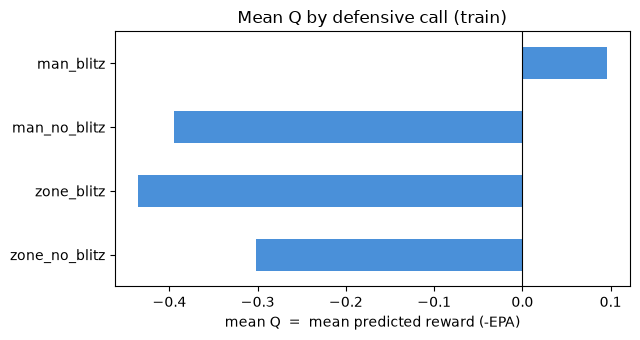

In [9]:
fig, ax = plt.subplots(figsize=(6.5, 3.5))
mean_q.plot.barh(ax=ax, color="#4A90D9")
ax.set_xlabel("mean Q  =  mean predicted reward (-EPA)")
ax.set_title("Mean Q by defensive call (train)")
ax.axvline(0, color="k", lw=0.8); plt.tight_layout(); plt.show()

## Step 5 — Off-policy evaluation (OPE) & the smoke test

OPE estimates the value of *any* candidate policy from logged data. V1 uses the
**Direct Method**: plug the Q-model into the policy and average,
`V(π) = E_s Σ_a π(a|s)·Q(s,a)`. It's biased if Q is misspecified (V2 makes it
doubly-robust), but it's the right first estimator.

Before trusting *any* candidate policy, we run the mandated **smoke test**: does
OPE recover the **behavior policy's own average reward**? Three numbers should
agree — the empirical mean reward, the Direct Method on the taken action, and the
Direct Method under π_b.

In [ ]:
rec = behavior_recovery_check(train, q, beh)
pd.Series({
    "empirical reward": rec["empirical_reward"],
    "DM (taken action)": rec["dm_taken_action"],
    "DM (under pi_b)": rec["dm_under_pi_b"],
    "recovery gap": rec["recovery_gap"],
    "smoke test": "PASS" if rec["passes"] else "FAIL",
}).to_frame("value")

If the smoke test passes, the OPE machinery is at least self-consistent on
the behavior policy. **It does not guarantee off-policy estimates are
trustworthy** — as the next step makes vivid.

## Step 6 — Policy learning & evaluation

The V1 policy is **behavior-constrained greedy**:

`π*(s) = argmax_a Q(s, a)  subject to  π_b(a|s) ≥ threshold`

The constraint is V1's stand-in for the pessimism/positivity discipline that CQL
formalizes later: we refuse to recommend a call the DC effectively never makes in
that kind of state, because Q has no support there. We then evaluate the learned
policy against π_b **on the held-out season**.

In [ ]:
policy = learn_greedy_policy(train, q, beh, cfg)
out = policy.act(test.df)

q_all_test = q.predict_all_actions(test.df)
v_behavior = dm_policy_value(q_all_test, beh.propensity(test.df))
v_greedy   = dm_policy_value(q_all_test, out["policy_probs"])
agree = float((out["chosen"] == test.df[ds.action_col].to_numpy()).mean())

pd.DataFrame([
    {"policy": "behavior (pi_b)", "value": v_behavior.value,
     "ci_lo": v_behavior.ci95[0], "ci_hi": v_behavior.ci95[1]},
    {"policy": "greedy (pi*)", "value": v_greedy.value,
     "ci_lo": v_greedy.ci95[0], "ci_hi": v_greedy.ci95[1]},
]).set_index("policy")

estimated lift: +1.167 reward/play
greedy policy agrees with the DC on 24.8% of holdout plays


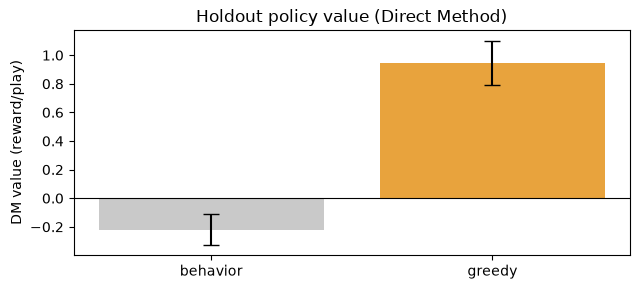

In [12]:
print(f"estimated lift: {v_greedy.value - v_behavior.value:+.3f} reward/play")
print(f"greedy policy agrees with the DC on {agree:.1%} of holdout plays")

fig, ax = plt.subplots(figsize=(6.5, 3))
vals = [v_behavior.value, v_greedy.value]
errs = [[v_behavior.value - v_behavior.ci95[0], v_greedy.value - v_greedy.ci95[0]]]*2
ax.bar(["behavior", "greedy"], vals, color=["#C9C9C9", "#E8A33D"],
       yerr=[[v_behavior.value-v_behavior.ci95[0], v_greedy.value-v_greedy.ci95[0]],
             [v_behavior.ci95[1]-v_behavior.value, v_greedy.ci95[1]-v_greedy.value]],
       capsize=6)
ax.set_ylabel("DM value (reward/play)"); ax.axhline(0, color="k", lw=0.8)
ax.set_title("Holdout policy value (Direct Method)"); plt.tight_layout(); plt.show()

### ⚠️ The deliberately-wrong part

Look at the greedy value. A whole play's EPA realistically lives in about
`[-1, +1]`, so any "reward/play" much beyond that is **physically impossible**.
The greedy estimate blows past it. This is textbook **Direct-Method
extrapolation**: with only a few hundred plays, ridge-Q produces wild values for
calls that are rare in a given state, and the greedy `argmax` deliberately
*seeks out* those inflated values.

Note the tension: the **smoke test passed** (DM recovers π_b's mean reward) while
the **off-policy estimate is nonsense**. That is precisely the failure mode V2
fixes with **doubly-robust OPE + causal pessimism**. Seeing it here, in a
pipeline we can step through, is exactly what the walking skeleton is for.

## Example recommendations

Finally, a few holdout situations with the policy's call, its Q value, what the
DC actually did, and which calls had enough behavioral support to be considered.

In [13]:
rows = []
sample = test.df.sample(min(6, len(test.df)), random_state=0).index
for i in sample:
    r = policy.act(test.df.loc[[i]])
    a = int(r["chosen"][0]); s = test.df.loc[i]
    supported = [ds.action_labels[j] for j in range(ds.n_actions) if r["support"][0, j]]
    rows.append({
        "situation": f"3rd & {s['ydstogo']:.0f}, {s['formation']}, "
                     f"ball on {100 - s['yardline_100']:.0f}, score {s['score_diff']:+.0f}",
        "recommended": ds.action_labels[a],
        "Q": r["q_all"][0][a],
        "DC actually called": ds.action_labels[int(s['action'])],
        "# supported calls": len(supported),
    })
pd.DataFrame(rows)

,situation,recommended,Q,DC actually called,# supported calls
0,"3rd & 13, SHOTGUN, ball on 70, score -7",man_blitz,+2.0564,man_blitz,3
1,"3rd & 7, SHOTGUN, ball on 55, score +7",zone_blitz,+1.3593,zone_blitz,4
2,"3rd & 6, SHOTGUN, ball on 9, score -18",zone_blitz,+6.5786,man_blitz,4
3,"3rd & 3, SHOTGUN, ball on 84, score -20",man_blitz,+0.8029,zone_blitz,3
4,"3rd & 18, SHOTGUN, ball on 58, score +14",man_no_blitz,+0.5565,zone_no_blitz,4
5,"3rd & 4, SHOTGUN, ball on 29, score -10",zone_no_blitz,+0.5477,zone_no_blitz,4


## Summary & what's next (V2)

**V1 delivers a complete, debuggable loop:** real SF 3rd-down data → pre-snap
(S, A, R) → logistic π_b (calibration tracked) → ridge Q → Direct-Method OPE with
a passing behavior-recovery smoke test → behavior-constrained greedy policy,
evaluated on a held-out season.

**What V1 honestly reveals** — and hands to V2 as concrete work items:

- **Direct-Method extrapolation** → doubly-robust (AIPW) OPE.
- **Off-support optimism** → CQL/IQL and causal pessimism in policy learning.
- **π_b below baseline on tiny data** → calibrated GBM behavior model.
- **Unobserved `coach_read` confounding** → sensitivity analysis that bounds it.
- **Small action support** → richer, properly-charted labels and more data.

That's the walking-skeleton payoff: every wrong number here names the next thing
to build.